In [1]:
from mfg import MFG_config, MFG
import numpy as np
from detect_major import detect_major_relaxed,make_example,detect_major_gap

In [2]:
# ── Simulation grid ──────────────────────────────────────────────────────────
T   = 1       # time horizon (Section 6)
Ndt = 1000    # time steps  → dt = 0.001

# ── Major bank parameters (Fig B.5, Fig B.6) ─────────────────────────────────
G        = 0.5   # relative market size of major bank  (F = 1-G = 0.5)
a        = 5     # minor bank mean-reversion rate (Section 6.2 baseline)
a_0      = a * G # = 2.5  market-clearing condition (eq 2.8): a_0 = a*G
sigma_0  = 1.0   # major bank reserve volatility
q_0      = 1.0   # major bank incentive to trade with central bank  (Fig B.5)
epslon_0 = 10.0  # major bank running penalty on reserve deviation  (Fig B.6)
c_0      = 0.0   # major bank terminal penalty                       (Fig B.6)

# ── Minor bank parameters (Fig B.5) ──────────────────────────────────────────
sigma    = 1.0   # minor bank reserve volatility
q        = 1.0   # minor bank incentive to trade with central bank
epslon   = 1.5   # minor bank running penalty  (must satisfy q^2 <= epslon)
c        = 0.0   # minor bank terminal penalty

# ── Monte Carlo ───────────────────────────────────────────────────────────────
N     = 700      # number of minor banks (Section 6)
N_sim = 300  # Monte Carlo paths     (Section 6)

cfg = MFG_config(
    T=T, Ndt=Ndt,
    a_0=a_0, sigma_0=sigma_0, c_0=c_0, epslon_0=epslon_0, q_0=q_0,
    a=a,     sigma=sigma,     c=c,     epslon=epslon,       q=q,
    G=G,
)
print(cfg)

MFG_config: {'T': 1, 'Ndt': 1000, 'dt': 0.001, 'a_0': 2.5, 'sigma_0': 1.0, 'c_0': 0.0, 'epslon_0': 10.0, 'q_0': 1.0, 'a': 5, 'sigma': 1.0, 'c': 0.0, 'epslon': 1.5, 'q': 1.0, 'G': 0.5, 'F': 0.5}


In [3]:
mfg = MFG(cfg)
mfg.solve_ODE()
X, x_bar_obs, true_idx = make_example(mfg, N)

In [4]:
print("=== Relaxation (Tier 2, observed mean field) ===")
prob, hist = detect_major_relaxed(mfg, X, x_bar_obs,n_steps=200, verbose=True)
pred = int(prob.argmax().item())
print(f"predicted={pred}  true={true_idx}  correct={pred==true_idx}")
print("top-3 prob:", np.round(np.sort(prob.numpy())[::-1][:3], 3))


=== Relaxation (Tier 2, observed mean field) ===
  step    0  J=1.4261e+06  argmax=373
  step   10  J=1.4261e+06  argmax=192
  step   20  J=1.4262e+06  argmax=192
  step   30  J=1.4262e+06  argmax=192
  step   40  J=1.4262e+06  argmax=192
  step   50  J=1.4262e+06  argmax=192
  step   60  J=1.4262e+06  argmax=192
  step   70  J=1.4263e+06  argmax=192
  step   80  J=1.4263e+06  argmax=192
  step   90  J=1.4263e+06  argmax=192
  step  100  J=1.4263e+06  argmax=192
  step  110  J=1.4263e+06  argmax=192
  step  120  J=1.4263e+06  argmax=192
  step  130  J=1.4263e+06  argmax=192
  step  140  J=1.4263e+06  argmax=192
  step  150  J=1.4263e+06  argmax=192
  step  160  J=1.4263e+06  argmax=192
  step  170  J=1.4263e+06  argmax=192
  step  180  J=1.4263e+06  argmax=192
  step  190  J=1.4263e+06  argmax=192
  step  199  J=1.4263e+06  argmax=192
predicted=192  true=192  correct=True
top-3 prob: [0.765 0.055 0.05 ]


In [5]:
print("\n=== Relaxation (Tier 3, mean field unobserved -- estimated from X) ===")
prob, hist = detect_major_relaxed(mfg, X,n_steps=200, verbose=True)
pred = int(prob.argmax().item())
print(f"predicted={pred}  true={true_idx}  correct={pred==true_idx}")
print("top-3 prob:", np.round(np.sort(prob.numpy())[::-1][:3], 3))



=== Relaxation (Tier 3, mean field unobserved -- estimated from X) ===
  step    0  J=1.4261e+06  argmax=373
  step   10  J=1.4261e+06  argmax=192
  step   20  J=1.4262e+06  argmax=192
  step   30  J=1.4262e+06  argmax=192
  step   40  J=1.4262e+06  argmax=192
  step   50  J=1.4262e+06  argmax=192
  step   60  J=1.4262e+06  argmax=192
  step   70  J=1.4263e+06  argmax=192
  step   80  J=1.4263e+06  argmax=192
  step   90  J=1.4263e+06  argmax=192
  step  100  J=1.4263e+06  argmax=192
  step  110  J=1.4263e+06  argmax=192
  step  120  J=1.4263e+06  argmax=192
  step  130  J=1.4263e+06  argmax=192
  step  140  J=1.4263e+06  argmax=192
  step  150  J=1.4263e+06  argmax=192
  step  160  J=1.4263e+06  argmax=192
  step  170  J=1.4263e+06  argmax=192
  step  180  J=1.4263e+06  argmax=192
  step  190  J=1.4263e+06  argmax=192
  step  199  J=1.4263e+06  argmax=192
predicted=192  true=192  correct=True
top-3 prob: [0.789 0.075 0.033]


## Experiments: Scale test (N) and Signal test (G)

Four experiments: Tier 2 (observed mean field) and Tier 3 (estimated mean field), each swept over N and G.  
**Metrics**: Top-1 Accuracy, Mean Rank of true major (1 = best), Mean probability mass on true major.

In [6]:

# ── Shared helpers for all four experiments ───────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# Lighter config for sweeps: Ndt=200 keeps each detection call fast.
BASE_KW = dict(T=1.0, Ndt=200,
               sigma_0=1.0, c_0=0.0, epslon_0=10.0, q_0=1.0,
               sigma=1.0,   c=0.0,   epslon=1.5,    q=1.0)

def make_mfg(G=0.5, a=5.0):
    """Build and solve a fresh MFG, enforcing a_0 = a*G (market-clearing)."""
    cfg = MFG_config(**BASE_KW, G=G, a=a, a_0=a * G)
    m = MFG(cfg)
    m.solve_ODE()
    return m

def run_sweep(mfg, N_val, tier, n_seeds=50, n_steps=400):
    """
    tier=2: observed x_bar passed to detector.
    tier=3: x_bar_obs=None, detector estimates mean field from X.
    Returns Top-1 Accuracy, Mean Rank (1=best), Mean w[true_idx].
    """
    acc, ranks, w_trues = [], [], []
    for s in range(n_seeds):
        X, xbar_obs, true_idx = make_example(mfg, N_val, seed=1000 + s)
        xbar_arg = xbar_obs if tier == 2 else None
        p, _ = detect_major_relaxed(mfg, X, xbar_arg, n_steps=n_steps)
        p_np = p.numpy()
        acc.append(int(p.argmax()) == true_idx)
        ranks.append(int((p_np > p_np[true_idx]).sum()) + 1)   # 1 = top rank
        w_trues.append(float(p_np[true_idx]))
    return {'Top-1 Acc':   np.mean(acc),
            'Mean Rank':   np.mean(ranks),
            'Mean w[true]': np.mean(w_trues)}

def show_table(results, index_name, title):
    df = pd.DataFrame(results).T
    df.index.name = index_name
    print(f"\n{'─'*50}\n{title}\n{'─'*50}")
    print(df.round(3).to_string())
    return df

# Base MFG used for N-scale tests (G fixed at 0.5)
mfg_base = make_mfg(G=0.5)
N_vals = [64, 256, 512]
G_vals = [0.1,0.3, 0.5, 0.7, 0.9]
N_fixed = 200    # fixed N for G-signal tests


### Experiment 1 — Tier 3, Scale test (N = 50 / 200 / 500)
Mean field is **not** observed; detector estimates it as $\hat{\bar{x}}_t(w) = \frac{1}{N}\sum_i (1-w_i)\,x_i(t)$.  
Hypothesis: accuracy degrades as N grows because the prior shrinks to $1/(N+1)$ and the mean-field estimate becomes noisier.

In [7]:

# ── Experiment 1: Tier 3 · Scale test (G=0.5 fixed, vary N) ──────────────────
res_t3_N = {}
for N_val in N_vals:
    print(f"  Tier 3 | N={N_val:>3d} ...", end="", flush=True)
    res_t3_N[f"N={N_val}"] = run_sweep(mfg_base, N_val, tier=3)
    print(" done")

df_t3_N = show_table(res_t3_N, "N", "Tier 3 — Scale test  (estimated x̄,  G=0.5)")


  Tier 3 | N= 64 ... done
  Tier 3 | N=256 ... done
  Tier 3 | N=512 ... done

──────────────────────────────────────────────────
Tier 3 — Scale test  (estimated x̄,  G=0.5)
──────────────────────────────────────────────────
       Top-1 Acc  Mean Rank  Mean w[true]
N                                        
N=64         1.0        1.0         0.760
N=256        1.0        1.0         0.746
N=512        1.0        1.0         0.818


### Experiment 2 — Tier 3, Signal test (G = 0.1 / 0.4 / 0.8)
Mean field still unobserved. G controls how strongly the major bank moves the market state  
$m_t = F\bar{x}_t + G x^0_t$. Low G → major barely distinguishable from minors.

In [8]:

# ── Experiment 2: Tier 3 · Signal test (N=20 fixed, vary G) ──────────────────
res_t3_G = {}
for G_val in G_vals:
    mfg_g = make_mfg(G=G_val)
    print(f"  Tier 3 | G={G_val} ...", end="", flush=True)
    res_t3_G[f"G={G_val}"] = run_sweep(mfg_g, N_fixed, tier=3)
    print(" done")

df_t3_G = show_table(res_t3_G, "G", "Tier 3 — Signal test  (estimated x̄,  N=20)")


  Tier 3 | G=0.1 ... done
  Tier 3 | G=0.3 ... done
  Tier 3 | G=0.5 ... done
  Tier 3 | G=0.7 ... done
  Tier 3 | G=0.9 ... done

──────────────────────────────────────────────────
Tier 3 — Signal test  (estimated x̄,  N=20)
──────────────────────────────────────────────────
       Top-1 Acc  Mean Rank  Mean w[true]
G                                        
G=0.1       0.38       9.76         0.305
G=0.3       0.94       1.16         0.675
G=0.5       1.00       1.00         0.778
G=0.7       1.00       1.00         0.818
G=0.9       1.00       1.00         0.844


### Experiment 3 — Tier 2, Scale test (N = 5 / 20 / 50)
Mean field is **observed**. Lmaj is precomputed and w-free; only Lmin is w-coupled.  
Compare with Experiment 1 to quantify the cost of not observing the mean field.

In [9]:

# ── Experiment 3: Tier 2 · Scale test (G=0.5 fixed, vary N) ──────────────────
res_t2_N = {}
for N_val in N_vals:
    print(f"  Tier 2 | N={N_val:>3d} ...", end="", flush=True)
    res_t2_N[f"N={N_val}"] = run_sweep(mfg_base, N_val, tier=2)
    print(" done")

df_t2_N = show_table(res_t2_N, "N", "Tier 2 — Scale test  (observed x̄,  G=0.5)")


  Tier 2 | N= 64 ... done
  Tier 2 | N=256 ... done
  Tier 2 | N=512 ... done

──────────────────────────────────────────────────
Tier 2 — Scale test  (observed x̄,  G=0.5)
──────────────────────────────────────────────────
       Top-1 Acc  Mean Rank  Mean w[true]
N                                        
N=64        0.96       1.04         0.716
N=256       1.00       1.00         0.731
N=512       1.00       1.00         0.806


### Experiment 4 — Tier 2, Signal test (G = 0.1 / 0.4 / 0.8)
Mean field observed. Compare with Experiment 2 to isolate how much of the G-sensitivity  
is due to the estimation error in the mean field vs. the intrinsic identification problem.

In [10]:

# ── Experiment 4: Tier 2 · Signal test (N=20 fixed, vary G) ──────────────────
res_t2_G = {}
for G_val in G_vals:
    mfg_g = make_mfg(G=G_val)
    print(f"  Tier 2 | G={G_val} ...", end="", flush=True)
    res_t2_G[f"G={G_val}"] = run_sweep(mfg_g, N_fixed, tier=2)
    print(" done")

df_t2_G = show_table(res_t2_G, "G", "Tier 2 — Signal test  (observed x̄,  N=20)")


  Tier 2 | G=0.1 ... done
  Tier 2 | G=0.3 ... done
  Tier 2 | G=0.5 ... done
  Tier 2 | G=0.7 ... done
  Tier 2 | G=0.9 ... done

──────────────────────────────────────────────────
Tier 2 — Signal test  (observed x̄,  N=20)
──────────────────────────────────────────────────
       Top-1 Acc  Mean Rank  Mean w[true]
G                                        
G=0.1       0.32      10.36         0.235
G=0.3       0.94       1.26         0.635
G=0.5       1.00       1.00         0.756
G=0.7       1.00       1.00         0.808
G=0.9       1.00       1.00         0.841


### Summary: Tier 2 vs Tier 3 comparison plots

ValueError: x and y must have same first dimension, but have shapes (3,) and (5,)

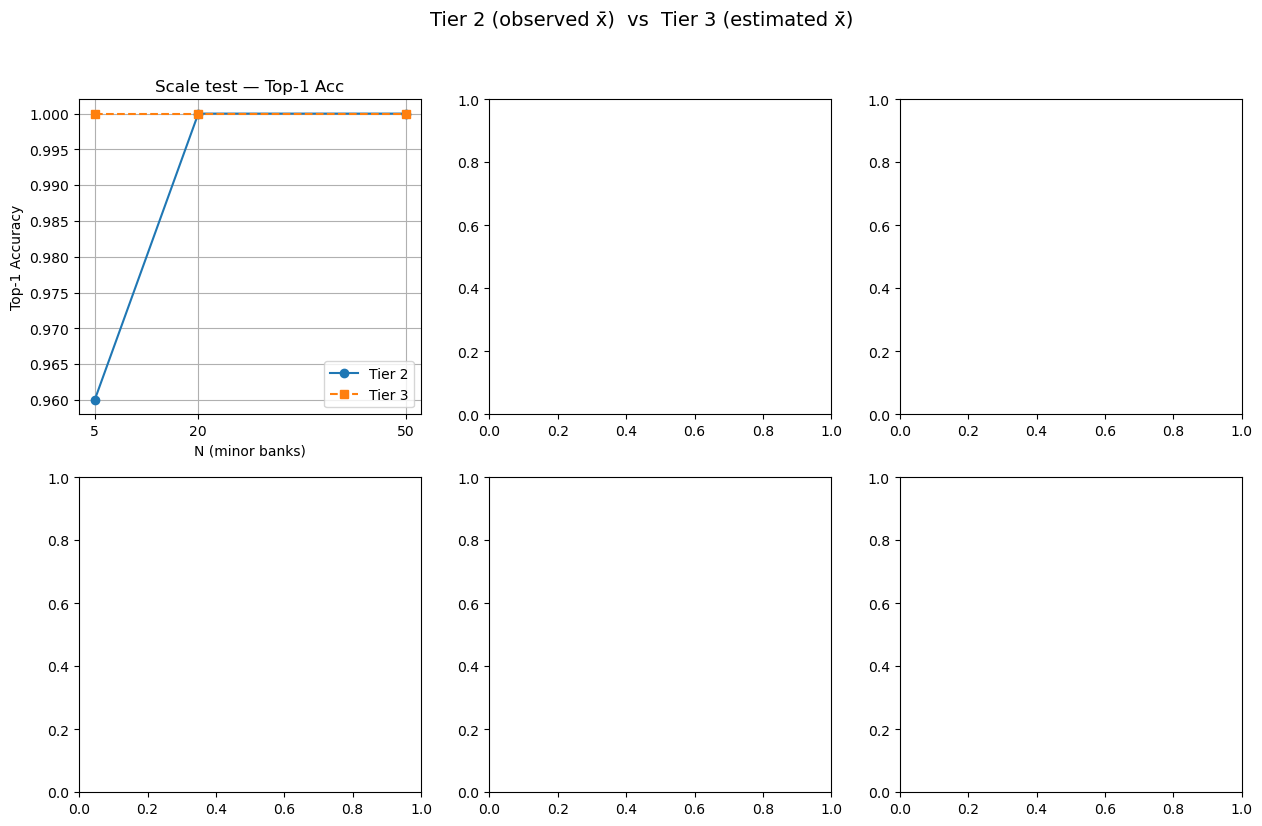

In [11]:

# ── Summary: 2×3 grid — Top-1 Acc / Mean Rank / Mean w[true] ─────────────────
metrics = ['Top-1 Acc', 'Mean Rank', 'Mean w[true]']
ylabels = ['Top-1 Accuracy', 'Mean Rank (↓ better)', 'Mean w[true] (↑ better)']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Tier 2 (observed x̄)  vs  Tier 3 (estimated x̄)", fontsize=14)

x_N_tick = [5, 20, 50]
x_G_tick = [0.1, 0.4, 0.8]

for col, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    # ── row 0: scale test ──
    ax = axes[0, col]
    ax.plot(x_N_tick, df_t2_N[metric].values, 'o-',  label='Tier 2')
    ax.plot(x_N_tick, df_t3_N[metric].values, 's--', label='Tier 3')
    ax.set_xlabel('N (minor banks)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Scale test — {metric}')
    ax.set_xticks(x_N_tick)
    ax.legend(); ax.grid(True)

    # ── row 1: signal test ──
    ax = axes[1, col]
    ax.plot(x_G_tick, df_t2_G[metric].values, 'o-',  label='Tier 2')
    ax.plot(x_G_tick, df_t3_G[metric].values, 's--', label='Tier 3')
    ax.set_xlabel('G (major influence)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Signal test — {metric}')
    ax.set_xticks(x_G_tick)
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()
